# 1.Adversarial attacks

In this project, we will discuss adversarial attacks on deep image classification models. Deep Neural Networks are a very powerful tool to recognize patterns in data, and, for example, perform image classification on a human-level. However, we have not tested yet how robust these models actually are. Can we "trick" the model and find failure modes? Can we design images that the networks naturally classify incorrectly? Due to the high classification accuracy on unseen test data, we would expect that this can be difficult. However, in 2014, a research group at Google and NYU showed that deep CNNs can be easily fooled, just by adding some salient but carefully constructed noise to the images. For instance, take a look at the example below (figure credit - [Goodfellow et al.](https://arxiv.org/pdf/1412.6572.pdf)):

<center width="100%" style="padding: 20px"><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial10/adversarial_example.svg?raw=1" width="550px"></center>

The image on the left is the original image from ImageNet, and a deep CNN classifies the image correctly as "panda" with a class likelihood of 57%. Nevertheless, if we add a little noise to every pixel of the image, the prediction of the model changes completely. Instead of a panda, our CNN tells us that the image contains a "gibbon" with the confidence of over 99%. For a human, however, these two images look exactly alike, and you cannot distinguish which one has noise added and which doesn't. While this first seems like a fun game to fool trained networks, it can have a serious impact on the usage of neural networks. More and more deep learning models are used in applications, such as for example autonomous driving. Imagine that someone who gains access to the camera input of the car, could make pedestrians "disappear" for the image understanding network by simply adding some noise to the input as shown below (the figure is taken from [J.H. Metzen et al.](https://openaccess.thecvf.com/content_ICCV_2017/papers/Metzen_Universal_Adversarial_Perturbations_ICCV_2017_paper.pdf)). The first row shows the original image with the semantic segmentation output on the right (pedestrians red), while the second row shows the image with small noise and the corresponding segmentation prediction. The pedestrian becomes invisible for the network, and the car would think the road is clear ahead.

<center width="100%" style="padding: 20px"><img src="https://github.com/phlippe/uvadlc_notebooks/blob/master/docs/tutorial_notebooks/tutorial10/adversarial_attacks_cityscapes_3.png?raw=1" width="600px"></center>

Some attack types don't even require to add noise, but minor changes on a stop sign can be already sufficient for the network to recognize it as a "50km/h" speed sign ([paper](https://arxiv.org/pdf/1707.08945.pdf), [paper](https://arxiv.org/pdf/1802.06430.pdf)). The consequences of such attacks can be devastating. Hence, every deep learning engineer who designs models for an application should be aware of the possibility of adversarial attacks.

To understand what makes CNNs vulnerable to such attacks, we will implement our own adversarial attack strategies in this notebook, and try to fool a deep neural network. Let's being with importing our standard libraries:

In [1]:
## Standard libraries
import os
import json
import math
import time
import numpy as np
import scipy.linalg

## Imports for plotting
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import set_matplotlib_formats
set_matplotlib_formats('svg', 'pdf') # For export
from matplotlib.colors import to_rgb
import matplotlib
matplotlib.rcParams['lines.linewidth'] = 2.0
import seaborn as sns
sns.set()

## Progress bar
from tqdm.notebook import tqdm

## PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.data as data
import torch.optim as optim
# Torchvision
import torchvision
from torchvision.datasets import CIFAR10
from torchvision import transforms
# PyTorch Lightning
try:
    import pytorch_lightning as pl
except ModuleNotFoundError: # Google Colab does not have PyTorch Lightning installed by default. Hence, we do it here if necessary
    !pip install --quiet pytorch-lightning>=1.4
    import pytorch_lightning as pl
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint

# Path to the folder where the datasets are/should be downloaded
DATASET_PATH = "../data"
# Path to the folder where the pretrained models are saved
CHECKPOINT_PATH = "../saved_models/hw04"

# Setting the seed
pl.seed_everything(42)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fetching the device that will be used throughout this notebook
device = torch.device("cpu") if not torch.cuda.is_available() else torch.device("cuda:0")
print("Using device", device)

/tmp/ipykernel_31/3961868876.py:13: DeprecationWarning: `set_matplotlib_formats` is deprecated since IPython 7.23, directly use `matplotlib_inline.backend_inline.set_matplotlib_formats()`
  set_matplotlib_formats('svg', 'pdf') # For export


Using device cuda:0


We have again a few download statements. This includes both a dataset, and a few pretrained patches we will use later.

In [2]:
import urllib.request
from urllib.error import HTTPError
import zipfile
# Github URL where the dataset is stored for this tutorial
base_url = "https://raw.githubusercontent.com/phlippe/saved_models/main/tutorial10/"
# Files to download
pretrained_files = [(DATASET_PATH, "TinyImageNet.zip"), (CHECKPOINT_PATH, "patches.zip")]
# Create checkpoint path if it doesn't exist yet
os.makedirs(DATASET_PATH, exist_ok=True)
os.makedirs(CHECKPOINT_PATH, exist_ok=True)

# For each file, check whether it already exists. If not, try downloading it.
for dir_name, file_name in pretrained_files:
    file_path = os.path.join(dir_name, file_name)
    if not os.path.isfile(file_path):
        file_url = base_url + file_name
        print(f"Downloading {file_url}...")
        try:
            urllib.request.urlretrieve(file_url, file_path)
        except HTTPError as e:
            print("Something went wrong. Please try to download the file from the GDrive folder, or contact the author with the full output including the following error:\n", e)
        if file_name.endswith(".zip"):
            print("Unzipping file...")
            with zipfile.ZipFile(file_path, 'r') as zip_ref:
                zip_ref.extractall(file_path.rsplit("/",1)[0])

Unzipping file...
Unzipping file...


## Deep CNNs on ImageNet

For our experiments in this notebook, we will use common CNN architectures trained on the ImageNet dataset. Such models are luckily provided by PyTorch's torchvision package, and hence we just need to load the model of our preference. For the results  default on Google Colab, we use a ResNet34.

In [3]:

os.environ["TORCH_HOME"] = CHECKPOINT_PATH
pretrained_model = torchvision.models.resnet34(weights='IMAGENET1K_V1')
pretrained_model = pretrained_model.to(device)

# No gradients needed for the network
pretrained_model.eval()
for p in pretrained_model.parameters():
    p.requires_grad = False

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to ../saved_models/hw04/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 189MB/s] 


To perform adversarial attacks, we also need a dataset to work on. Given that the CNN model has been trained on ImageNet, it is only fair to perform the attacks on data from ImageNet. For this, we provide a small set of pre-processed images from the original ImageNet dataset . Specifically, we have 5 images for each of the 1000 labels of the dataset. We can load the data below, and create a corresponding data loader.

In [4]:
# Mean and Std from ImageNet
NORM_MEAN = np.array([0.485, 0.456, 0.406])
NORM_STD = np.array([0.229, 0.224, 0.225])
# No resizing and center crop necessary as images are already preprocessed.
plain_transforms = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=NORM_MEAN,
                         std=NORM_STD)
])

# Load dataset and create data loader
imagenet_path = os.path.join(DATASET_PATH, "TinyImageNet/")
assert os.path.isdir(imagenet_path), f"Could not find the ImageNet dataset at expected path \"{imagenet_path}\". " + \
                                     f"Please make sure to have downloaded the ImageNet dataset here, or change the {DATASET_PATH=} variable."
dataset = torchvision.datasets.ImageFolder(root=imagenet_path, transform=plain_transforms)
data_loader = data.DataLoader(dataset, batch_size=32, shuffle=False, drop_last=False, num_workers=8)

# Load label names to interpret the label numbers 0 to 999
with open(os.path.join(imagenet_path, "label_list.json"), "r") as f:
    label_names = json.load(f)
    
def get_label_index(lab_str):
    assert lab_str in label_names, f"Label \"{lab_str}\" not found. Check the spelling of the class."
    return label_names.index(lab_str)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Before we start with our attacks, we should verify the performance of our model. As ImageNet has 1000 classes, simply looking at the accuracy is not sufficient to tell the performance of a model. Imagine a model that always predicts the true label as the second-highest class in its softmax output. Although we would say it recognizes the object in the image, it achieves an accuracy of 0. In ImageNet with 1000 classes, there is not always one clear label we can assign an image to. This is why for image classifications over so many classes, a common alternative metric is "Top-5 accuracy", which tells us how many times the true label has been within the 5 most-likely predictions of the model. As models usually perform quite well on those, we report the error (1 - accuracy) instead of the accuracy:

In [10]:
def eval_model(loader, transform_fn=None):
    correct_top1 = 0
    correct_top5 = 0
    total_samples = 0

    for batch_images, batch_labels in tqdm(loader, desc="Evaluating..."):
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.to(device)

        if transform_fn:
            batch_images = transform_fn(batch_images, batch_labels)

        with torch.no_grad():
            outputs = pretrained_model(batch_images)

        # Top-1 Accuracy
        predicted_top1 = outputs.argmax(dim=1)
        correct_top1 += (predicted_top1 == batch_labels).sum().item()

        # Top-5 Accuracy
        top5_predictions = outputs.topk(5, dim=1).indices
        correct_top5 += (top5_predictions == batch_labels.unsqueeze(1)).any(dim=1).sum().item()

        total_samples += batch_labels.size(0)

    top1_accuracy = correct_top1 / total_samples
    top5_accuracy = correct_top5 / total_samples

    print(f"Top-1 Error Rate: {100.0 * (1 - top1_accuracy):.2f}%")
    print(f"Top-5 Error Rate: {100.0 * (1 - top5_accuracy):.2f}%")

    return top1_accuracy, top5_accuracy


In [11]:
_ = eval_model(data_loader)

Evaluating...:   0%|          | 0/157 [00:00<?, ?it/s]

Top-1 Error Rate: 19.38%
Top-5 Error Rate: 4.38%


The ResNet34 achives a decent error rate of 4.3% for the top-5 predictions. Next, we can look at some predictions of the model to get more familiar with the dataset. The function below plots an image along with a bar diagram of its predictions. We also prepare it to show adversarial examples for later applications.

In [25]:
def visualize_prediction(image, true_label, prediction_logits, top_k=5, adversarial=None, perturbation=None):
    def _to_display_format(tensor_img):
        img = tensor_img.cpu().permute(1, 2, 0).numpy()
        img = (img * NORM_STD[None, None]) + NORM_MEAN[None, None]
        return np.clip(img, 0.0, 1.0)

    def _plot_bar(ax, probs, indices, true_label):
        colors = ["C2" if idx == true_label else "C0" for idx in indices]
        ax.barh(np.arange(top_k), probs * 100.0, color=colors, align='center')
        ax.set_yticks(np.arange(top_k))
        ax.set_yticklabels([label_names[i] for i in indices])
        ax.invert_yaxis()
        ax.set_xlabel("Confidence")
        ax.set_title("Predictions")

    if isinstance(image, torch.Tensor):
        image_np = _to_display_format(image)
        true_label = true_label.item()
    else:
        image_np = image

    # Choose subplot layout
    if adversarial is not None and perturbation is not None:
        fig, axes = plt.subplots(1, 5, figsize=(12, 2), gridspec_kw={'width_ratios': [1, 1, 1, 1, 2]})
    else:
        fig, axes = plt.subplots(1, 2, figsize=(10, 2), gridspec_kw={'width_ratios': [1, 1]})

    # Show original image
    axes[0].imshow(image_np)
    axes[0].set_title(label_names[true_label])
    axes[0].axis("off")

    # Show adversarial and noise if provided
    if adversarial is not None and perturbation is not None:
        adv_np = _to_display_format(adversarial)
        noise_np = perturbation.cpu().permute(1, 2, 0).numpy()
        noise_np = noise_np * 0.5 + 0.5  # Normalize to [0, 1]

        axes[1].imshow(adv_np)
        axes[1].set_title("Adversarial")
        axes[1].axis("off")

        axes[2].imshow(noise_np)
        axes[2].set_title("Noise")
        axes[2].axis("off")

        axes[3].axis("off")  # Spacer

    # Ensure predictions are probabilities
    if abs(prediction_logits.sum().item() - 1.0) > 1e-4:
        prediction_logits = torch.softmax(prediction_logits, dim=-1)

    top_probs, top_indices = prediction_logits.topk(top_k)
    top_probs = top_probs.cpu().numpy()
    top_indices = top_indices.cpu().numpy()

    # Draw bar plot for top-K predictions
    _plot_bar(axes[-1], top_probs, top_indices, true_label)

    plt.tight_layout()
    plt.show()
    plt.close()


Let's visualize a few images below:

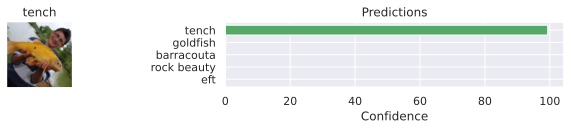

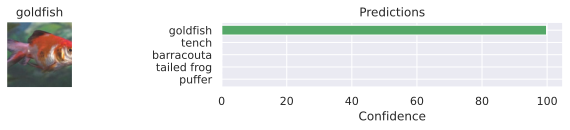

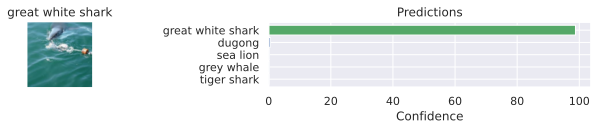

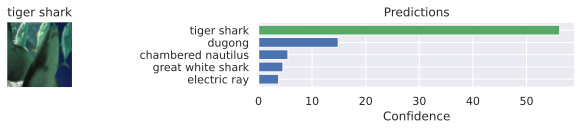

In [13]:
exmp_batch, label_batch = next(iter(data_loader))
with torch.no_grad():
    preds = pretrained_model(exmp_batch.to(device))
for i in range(1,17,5):
    visualize_prediction(exmp_batch[i], label_batch[i], preds[i])

The bar plot on the right shows the top-5 predictions of the model with their class probabilities. We denote the class probabilities with "confidence" as it somewhat resembles how confident the network is that the image is of one specific class. Some of the images have a highly peaked probability distribution, and we would expect the model to be rather robust against noise for those. However, we will see below that this is not always the case. Note that all of the images are of fish because the data loader doesn't shuffle the dataset. Otherwise, we would get different images every time we run the notebook, which would make it hard to discuss the results on the static version.

## White-box adversarial attacks

There have been proposed many possible adversarial attack strategies, which all share the same goal: alternate the data/image input only a little bit to have a great impact on the model's prediction. Specifically, if we look at the ImageNet predictions above, how can we have to change the image of the goldfish so that the model does not recognize the goldfish anymore? At the same time, the label of the image should not change, in the sense that a human would still clearly classify it as a goldfish. This is the same objective that the generator network has in the Generative Adversarial Network framework: try to fool another network (discriminator) by changing its input.

Adversarial attacks are usually grouped into "white-box" and "black-box" attacks. White-box attacks assume that we have access to the model parameter and can, for example, calculate the gradients with respect to the input (similar as in GANs). Black-box attacks on the other hand have the harder task of not having any knowledge about the network, and can only obtain predictions for an image, but no gradients or the like. In this notebook, we will focus on white-box attacks as they are usually easier to implement and follow the intuition of Generative Adversarial Networks (GAN) as studied in lecture 10.

### Fast Gradient Sign Method (FGSM)

One of the first attack strategies proposed is Fast Gradient Sign Method (FGSM), developed by [Ian Goodfellow et al.](https://arxiv.org/pdf/1412.6572.pdf) in 2014. Given an image, we create an adversarial example by the following expression:

$$\tilde{x} = x + \epsilon \cdot \text{sign}(\nabla_x J(\theta,x,y))$$

The term $J(\theta,x,y)$ represents the loss of the network for classifying input image $x$ as label $y$; $\epsilon$ is the intensity of the noise, and $\tilde{x}$ the final adversarial example. The equation resembles SGD and is actually nothing else than that. We change the input image $x$ in the direction of *maximizing* the loss $J(\theta,x,y)$. This is exactly the other way round as during training, where we try to minimize the loss. The sign function and $\epsilon$ can be seen as gradient clipping and learning rate specifically. We only allow our attack to change each pixel value by $\epsilon$. You can also see that the attack can be performed very fast, as it only requires a single forward and backward pass. Let's implement it below:

In [19]:
def fast_gradient_sign_method(model, imgs, labels, epsilon=0.02):
    # Determine prediction of the model
    inp_imgs = imgs.clone().requires_grad_()
    preds = model(inp_imgs.to(device))
    preds = F.log_softmax(preds, dim=-1)
    # Calculate loss by NLL
    loss = -torch.gather(preds, 1, labels.to(device).unsqueeze(dim=-1))
    loss.sum().backward()
    # Update image to adversarial example as written above
    noise_grad = torch.sign(inp_imgs.grad.to(imgs.device))
    fake_imgs = imgs + epsilon * noise_grad
    fake_imgs.detach_()
    return fake_imgs, noise_grad

The default value of $\epsilon=0.02$ corresponds to changing a pixel value by about 1 in the range of 0 to 255, e.g. changing 127 to 128. This difference is marginal and can often not be recognized by humans. Let's try it below on our example images:

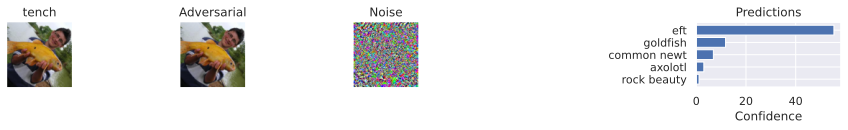

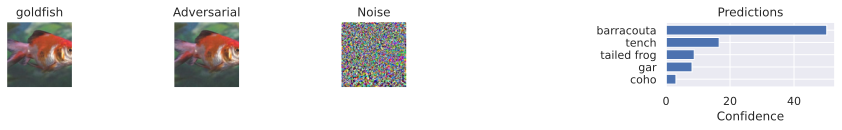

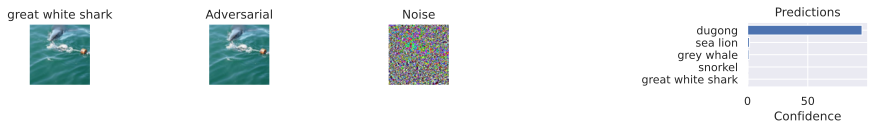

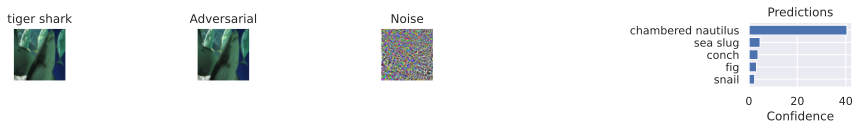

In [26]:
adv_imgs, noise_grad = fast_gradient_sign_method(pretrained_model, exmp_batch, label_batch, epsilon=0.02)
with torch.no_grad():
    adv_preds = pretrained_model(adv_imgs.to(device))

for i in range(1,17,5):
    visualize_prediction(exmp_batch[i], label_batch[i], adv_preds[i], adversarial=adv_imgs[i], perturbation=noise_grad[i])

Despite the minor amount of noise, we are able to fool the network on all of our examples. None of the labels have made it into the top-5 for the four images, showing that we indeed fooled the model. We can also check the accuracy of the model on the adversarial images:

In [28]:
_ = eval_model(data_loader, transform_fn=lambda x, y: fast_gradient_sign_method(pretrained_model, x, y, epsilon=0.02)[0])

Evaluating...:   0%|          | 0/157 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Top-1 Error Rate: 93.74%
Top-5 Error Rate: 60.82%


As expected, the model is fooled on almost every image at least for the top-1 error, and more than half don't have the true label in their top-5. This is a quite significant difference compared to the error rate of 4.3% on the clean images. However, note that the predictions remain semantically similar. For instance, in the images we visualized above, the tench is still recognized as another fish, as well as the great white shark being a dugong. FGSM could be adapted to increase the probability of a specific class instead of minimizing the probability of a label, but for those, there are usually better attacks such as the adversarial patch.

### Adversarial Patches

Instead of changing every pixel by a little bit, we can also try to change a small part of the image into whatever values we would like. In other words, we will create a small image patch that covers a minor part of the original image but causes the model to confidentially predict a specific class we choose. This form of attack is an even bigger threat in real-world applications than FSGM. Imagine a network in an autonomous car that receives a live image from a camera. Another driver could print out a specific pattern and put it on the back of his/her vehicle to make the autonomous car believe that the car is actually a pedestrian. Meanwhile, humans would not notice it. [Tom Brown et al.](https://arxiv.org/pdf/1712.09665.pdf) proposed a way of learning such adversarial image patches robustly in 2017 and provided a short demonstration on [YouTube](https://youtu.be/i1sp4X57TL4). Interestingly, if you add a small picture of the target class (here *toaster*) to the original image, the model does not pick it up at all. A specifically designed patch, however, which only roughly looks like a toaster, can change the network's prediction instantaneously.

[![Adversarial patch in real world](https://img.youtube.com/vi/i1sp4X57TL4/0.jpg)](https://youtu.be/i1sp4X57TL4)

Let's take a closer look at how we can actually train such patches. The general idea is very similar to FSGM in the sense that we calculate gradients for the input, and update our adversarial input correspondingly. However, there are also some differences in the setup. Firstly, we do not calculate a gradient for every pixel. Instead, we replace parts of the input image with our patch and then calculate the gradients just for our patch. Secondly, we don't just do it for one image, but we want the patch to work with any possible image. Hence, we have a whole training loop where we train the patch using SGD. Lastly, image patches are usually designed to make the model predict a specific class, not just any other arbitrary class except the true label. For instance, we can try to create a patch for the class "toaster" and train the patch so that our pretrained model predicts the class "toaster" for any image with the patch in it.

Additionally, to the setup described above, there are a couple of design choices we can take. For instance, [Brown et al.](https://arxiv.org/pdf/1712.09665.pdf) randomly rotated and scaled the patch during training before placing it at a random position in an input image. This makes the patch more robust to small changes and is necessary if we want to fool a neural network in a real-world application. For simplicity, we will only focus on making the patch robust to the location in the image. Given a batch of input images and a patch, we can add the patch as follows:

In [43]:
def place_patch(img, patch):
    for i in range(img.shape[0]):
        h_offset = np.random.randint(0,img.shape[2]-patch.shape[1]-1)
        w_offset = np.random.randint(0,img.shape[3]-patch.shape[2]-1)
        img[i,:,h_offset:h_offset+patch.shape[1],w_offset:w_offset+patch.shape[2]] = patch_forward(patch)
    return img

The patch itself will be an `nn.Parameter` whose values are in the range between $-\infty$ and $\infty$. Images are, however, naturally limited in their range, and thus we write a small function that maps the parameter into the image value range of ImageNet:

In [30]:
TENSOR_MEANS, TENSOR_STD = torch.FloatTensor(NORM_MEAN)[:,None,None], torch.FloatTensor(NORM_STD)[:,None,None]
def patch_forward(patch):
    # Map patch values from [-infty,infty] to ImageNet min and max
    patch = (torch.tanh(patch) + 1 - 2 * TENSOR_MEANS) / (2 * TENSOR_STD)
    return patch

Before looking at the actual training code, we can write a small evaluation function. We evaluate the success of a patch by how many times we were able to fool the network into predicting our target class. A simple function for this is implemented below.

In [ ]:
def evaluate_patch_effectiveness(model, patch, dataloader, target_label):
    model.eval()
    successful_top1 = 0
    successful_top5 = 0
    total_non_target = 0

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating Patch...", leave=False):
            labels = labels.to(device)

            for _ in range(4):  # Try 4 random placements per image
                patched_images = place_patch(images.clone(), patch)
                patched_images = patched_images.to(device)

                outputs = model(patched_images)
                preds_top1 = outputs.argmax(dim=-1)
                preds_top5 = outputs.topk(5, dim=-1).indices

                mask = (labels != target_label)
                total_non_target += mask.sum().item()

                successful_top1 += ((preds_top1 == target_label) & mask).sum().item()
                successful_top5 += ((preds_top5 == target_label).any(dim=-1) & mask).sum().item()

    accuracy_top1 = successful_top1 / total_non_target
    accuracy_top5 = successful_top5 / total_non_target

    return accuracy_top1, accuracy_top5


Finally, we can look at the training loop. Given a model to fool, a target class to design the patch for, and a size $k$ of the patch in the number of pixels, we first start by creating a parameter of size $3\times k\times k$. These are the only parameters we will train, and the network itself remains untouched. We use a simple SGD optimizer with momentum to minimize the classification loss of the model given the patch in the image. While we first start with a very high loss due to the good initial performance of the network, the loss quickly decreases once we start changing the patch. In the end, the patch will represent patterns that are characteristic of the class. For instance, if we would want the model to predict a "goldfish" in every image, we would expect the pattern to look somewhat like a goldfish. Over the iterations, the model finetunes the pattern and, hopefully, achieves a high fooling accuracy.

In [ ]:
def run_patch_attack(model, target_label, patch_dim=64, epochs=5):
    # Split dataset into training and validation
    train_subset, val_subset = torch.utils.data.random_split(dataset, [4500, 500])
    train_loader = data.DataLoader(train_subset, batch_size=32, shuffle=True, drop_last=True, num_workers=8)
    val_loader = data.DataLoader(val_subset, batch_size=32, shuffle=False, drop_last=False, num_workers=4)

    # Prepare patch and optimizer
    if not isinstance(patch_dim, tuple):
        patch_dim = (patch_dim, patch_dim)

    patch_tensor = nn.Parameter(torch.zeros(3, patch_dim[0], patch_dim[1]), requires_grad=True)
    optimizer = torch.optim.SGD([patch_tensor], lr=0.1, momentum=0.8)
    loss_fn = nn.CrossEntropyLoss()

    # Training loop
    for epoch in range(epochs):
        progress_bar = tqdm(train_loader, desc=f"Epoch {epoch}", leave=False)
        for batch_imgs, _ in progress_bar:
            patched_imgs = place_patch(batch_imgs.clone(), patch_tensor)
            patched_imgs = patched_imgs.to(device)

            outputs = model(patched_imgs)
            target_labels = torch.full((patched_imgs.size(0),), target_label, dtype=torch.long, device=device)

            loss = loss_fn(outputs, target_labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            progress_bar.set_description(f"Epoch {epoch}, Loss: {loss.item():.2f}")

    # Final evaluation
    acc_top1, acc_top5 = evaluate_patch_effectiveness(model, patch_tensor, val_loader, target_label)

    return patch_tensor._


To get some experience with what to expect from an adversarial patch attack, we want to train multiple patches for different classes. As the training of a patch can take one or two minutes on a GPU, we have provided a couple of pre-trained patches including their results on the full dataset. The results are saved in a JSON file, which is loaded below.

In [32]:
# Load evaluation results of the pretrained patches
json_results_file = os.path.join(CHECKPOINT_PATH, "patch_results.json")
json_results = {}
if os.path.isfile(json_results_file):
    with open(json_results_file, "r") as f:
        json_results = json.load(f)

# If you train new patches, you can save the results via calling this function
def save_results(patch_dict):
    result_dict = {cname: {psize: [t.item() if isinstance(t, torch.Tensor) else t
                                   for t in patch_dict[cname][psize]["results"]]
                           for psize in patch_dict[cname]}
                   for cname in patch_dict}
    with open(os.path.join(CHECKPOINT_PATH, "patch_results.json"), "w") as f:
        json.dump(result_dict, f, indent=4)

Additionally, we implement a function to train and evaluate patches for a list of classes and patch sizes. The pretrained patches include the classes *toaster*, *goldfish*, *school bus*, *lipstick*, and *pineapple*. We chose the classes arbitrarily to cover multiple domains (animals, vehicles, fruits, devices, etc.). We trained each class for three different patch sizes: $32\times32$ pixels, $48\times48$ pixels, and $64\times64$ pixels. We can load them in the two cells below.

In [33]:
def load_or_create_patches(target_class_names, patch_sizes_list):
    patches_summary = {}

    for class_name in target_class_names:
        patches_summary[class_name] = {}

        class_index = label_names.index(class_name)

        for size in patch_sizes_list:
            patch_file = os.path.join(CHECKPOINT_PATH, f"{class_name}_{size}_patch.pt")

            # Load or train patch
            if not os.path.isfile(patch_file):
                trained_patch, validation_metrics = run_patch_attack(
                    model=pretrained_model,
                    target_label=class_index,
                    patch_dim=size,
                    epochs=5
                )
                print(f"Validation for '{class_name}' with patch size {size}: {validation_metrics}")
                torch.save(trained_patch, patch_file)
            else:
                trained_patch = torch.load(patch_file)

            # Evaluate or load existing results
            if class_name in json_results and str(size) in json_results[class_name]:
                evaluation_result = json_results[class_name][str(size)]
            else:
                evaluation_result = evaluate_patch_effectiveness(
                    pretrained_model, trained_patch, data_loader, class_index
                )

            patches_summary[class_name][size] = {
                "patch": trained_patch,
                "results": evaluation_result
            }

    return patches_summary


Feel free to add any additional classes and/or patch sizes.

In [34]:
class_names = ['toaster', 'goldfish', 'school bus', 'lipstick', 'pineapple']
patch_sizes = [32, 48, 64]

patch_dict = load_or_create_patches(class_names, patch_sizes)
# save_results(patch_dict) # Uncomment if you add new class names and want to save the new results

/tmp/ipykernel_31/3060447409.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  trained_patch = torch.load(patch_file)


Before looking at the quantitative results, we can actually visualize the patches.

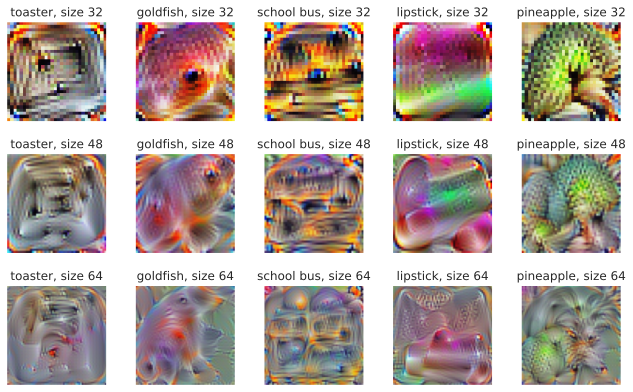

In [35]:
def show_patches():
    fig, ax = plt.subplots(len(patch_sizes), len(class_names), figsize=(len(class_names)*2.2, len(patch_sizes)*2.2))
    for c_idx, cname in enumerate(class_names):
        for p_idx, psize in enumerate(patch_sizes):
            patch = patch_dict[cname][psize]["patch"]
            patch = (torch.tanh(patch) + 1) / 2 # Parameter to pixel values
            patch = patch.cpu().permute(1, 2, 0).numpy()
            patch = np.clip(patch, a_min=0.0, a_max=1.0)
            ax[p_idx][c_idx].imshow(patch)
            ax[p_idx][c_idx].set_title(f"{cname}, size {psize}")
            ax[p_idx][c_idx].axis('off')
    fig.subplots_adjust(hspace=0.3, wspace=0.3)
    plt.show()
show_patches()

We can see a clear difference between patches of different classes and sizes. In the smallest size, $32\times 32$ pixels, some of the patches clearly resemble their class. For instance, the goldfish patch clearly shows a goldfish. The eye and the color are very characteristic of the class. Overall, the patches with $32$ pixels have very strong colors that are typical for their class (yellow school bus, pink lipstick, greenish pineapple). The larger the patch becomes, the more stretched the pattern becomes. For the goldfish, we can still spot regions that might represent eyes and the characteristic orange color, but it is not clearly a single fish anymore. For the pineapple, we might interpret the top part of the image as the leaves of pineapple fruit, but it is more abstract than our small patches. Nevertheless, we can easily spot the alignment of the patch to class, even on the largest scale.

Let's now look at the quantitative results.

In [36]:
%%html
<!-- Some HTML code to increase font size in the following table -->
<style>
th {font-size: 120%;}
td {font-size: 120%;}
</style>

In [37]:
import tabulate
from IPython.display import display, HTML

def show_table(top_1=True):
    i = 0 if top_1 else 1
    table = [[name] + [f"{(100.0 * patch_dict[name][psize]['results'][i]):4.2f}%" for psize in patch_sizes]
             for name in class_names]
    display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["Class name"] + [f"Patch size {psize}x{psize}" for psize in patch_sizes])))

First, we will create a table of top-1 accuracy, meaning that how many images have been classified with the target class as highest prediction?

In [38]:
show_table(top_1=True)

Class name,Patch size 32x32,Patch size 48x48,Patch size 64x64
toaster,48.89%,90.48%,98.58%
goldfish,69.53%,93.53%,98.34%
school bus,78.79%,93.95%,98.22%
lipstick,43.36%,86.05%,96.41%
pineapple,79.74%,94.48%,98.72%


The clear trend, that we would also have expected, is that the larger the patch, the easier it is to fool the model. For the largest patch size of $64\times 64$, we are able to fool the model on almost all images, despite the patch covering only 8% of the image. The smallest patch actually covers 2% of the image, which is almost neglectable. Still, the fooling accuracy is quite remarkable. A large variation can be however seen across classes. While *school bus* and *pineapple* seem to be classes that were easily predicted, *toaster* and *lipstick* seem to be much harder for creating a patch. It is hard to intuitively explain why our patches underperform on those classes. Nonetheless, a fooling accuracy of >40% is still very good for such a tiny patch.

Let's also take a look at the top-5 accuracy:

In [39]:
show_table(top_1=False)

Class name,Patch size 32x32,Patch size 48x48,Patch size 64x64
toaster,72.02%,98.12%,99.93%
goldfish,86.31%,99.07%,99.95%
school bus,91.64%,99.15%,99.89%
lipstick,70.10%,96.86%,99.73%
pineapple,92.23%,99.26%,99.96%


We see a very similar pattern across classes and patch sizes. The patch size $64$ obtains >99.7% top-5 accuracy for any class, showing that we can almost fool the network on any image. A top-5 accuracy of >70% for the hard classes and small patches is still impressive and shows how vulnerable deep CNNs are to such attacks.

Finally, let's create some example visualizations of the patch attack in action.

In [46]:


def perform_patch_attack(patch):
    patch_batch = exmp_batch.clone()
    patch_batch = place_patch(patch_batch, patch)
    with torch.no_grad():
        patch_preds = pretrained_model(patch_batch.to(device))
    for i in range(1,17,5):
        visualize_prediction(patch_batch[i], label_batch[i], patch_preds[i])

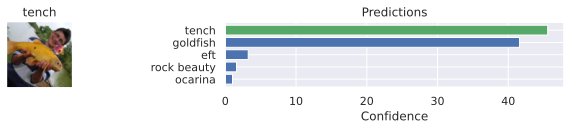

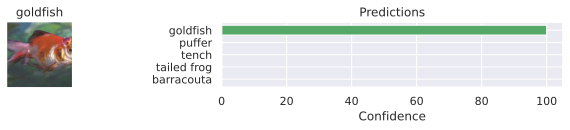

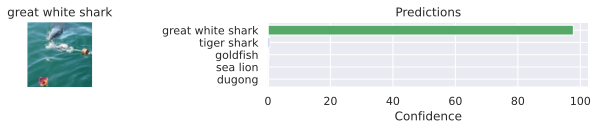

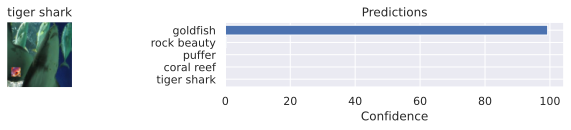

In [47]:
perform_patch_attack(patch_dict['goldfish'][32]['patch'])

The tiny goldfish patch can change all of the predictions to "goldfish" as top class. Note that the patch attacks work especially well if the input image is semantically similar to the target class (e.g. a fish and the target class "goldfish" works better than an airplane image with that patch). Nevertheless, we can also let the network predict semantically dis-similar classes by using a larger patch:

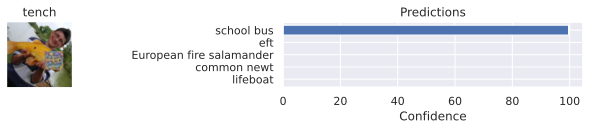

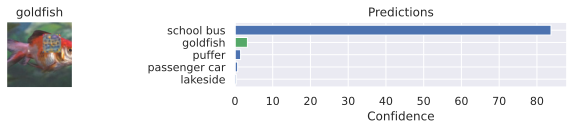

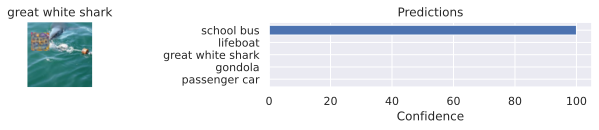

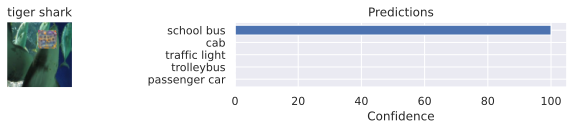

In [48]:
perform_patch_attack(patch_dict['school bus'][64]['patch'])

Although none of the images have anything to do with an American school bus, the high confidence of often 100% shows how powerful such attacks can be. With a few lines of code and access to the model, we were able to generate patches that we add to any image to make the model predict any class we want.

### Transferability of white-box attacks

FGSM and the adversarial patch attack were both focused on one specific image. However, can we transfer those attacks to other models? The adversarial patch attack as proposed in [Brown et al.](https://arxiv.org/pdf/1712.09665.pdf), was originally trained on multiple models, and hence was also able to work on many different network architecture. But how different are the patches for different models anyway? For instance, let's evaluate some of our patches trained above on a different network, e.g. DenseNet121.

In [49]:
transfer_model = torchvision.models.densenet121(weights='IMAGENET1K_V1')
transfer_model = transfer_model.to(device)

# No gradients needed for the network
transfer_model.eval()
for p in transfer_model.parameters():
    p.requires_grad = False

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to ../saved_models/hw04/hub/checkpoints/densenet121-a639ec97.pth
100%|██████████| 30.8M/30.8M [00:00<00:00, 155MB/s] 


Feel free to change the class name and/or patch size below to test out different patches.

In [53]:
def eval_patch(model, patch, val_loader, target_class):
    model.eval()
    tp, tp_5, counter = 0., 0., 0.
    with torch.no_grad():
        for img, img_labels in tqdm(val_loader, desc="Validating...", leave=False):
            # For stability, place the patch at 4 random locations per image, and average the performance
            for _ in range(4): 
                patch_img = place_patch(img, patch)
                patch_img = patch_img.to(device)
                img_labels = img_labels.to(device)
                pred = model(patch_img)
                # In the accuracy calculation, we need to exclude the images that are of our target class
                # as we would not "fool" the model into predicting those
                tp += torch.logical_and(pred.argmax(dim=-1) == target_class, img_labels != target_class).sum()
                tp_5 += torch.logical_and((pred.topk(5, dim=-1)[1] == target_class).any(dim=-1), img_labels != target_class).sum()
                counter += (img_labels != target_class).sum()
    acc = tp/counter
    top5 = tp_5/counter
    return acc, top5
class_name = 'pineapple'
patch_size = 64
print(f"Testing patch \"{class_name}\" of size {patch_size}x{patch_size}")

results = eval_patch(transfer_model,
                     patch_dict[class_name][patch_size]["patch"],
                     data_loader,
                     target_class=label_names.index(class_name))

print(f"Top-1 fool accuracy: {(results[0] * 100.0):4.2f}%")
print(f"Top-5 fool accuracy: {(results[1] * 100.0):4.2f}%")

Testing patch "pineapple" of size 64x64


Validating...:   0%|          | 0/157 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Top-1 fool accuracy: 64.81%
Top-5 fool accuracy: 82.11%


Although the fool accuracy is significantly lower than on the original ResNet34, it still has a considerable impact on DenseNet although the networks have completely different architectures and weights. If you would compare more patches and models, some would work better than others. However, one aspect which allows patch attacks to generalize well is if all the networks have been trained on the same data. In this case, all networks have been trained on ImageNet. Dataset biases make the networks recognize specific patterns in the underlying image data that humans would not have seen, and/or only work for the given dataset. This is why the knowledge of what data has been used to train a specific model is already worth a lot in the context of adversarial attacks.

## Protecting against adversarial attacks

There are many more attack strategies than just FGSM and adversarial patches that we haven't discussed and implemented ourselves here. However, what about the other perspective? What can we do to *protect* a network against adversarial attacks? The sad truth to this is: not much.

White-box attacks require access to the model and its gradient calculation. The easiest way of preventing this is by ensuring safe, private storage of the model and its weights. However, some attacks, called black-box attacks, also work without access to the model's parameters, or white-box attacks can also generalize as we have seen above on our short test on transferability.

So, how could we eventually protect a model? An intuitive approach would to train/finetune a model on such adversarial images, leading to an adversarial training similar to a GAN. During training, we would pretend to be the attacker, and use for example FGSM as an augmentation strategy. However, this usually just ends up in an oscillation of the defending network between weak spots. Another common trick to increase robustness against adversarial attacks is defensive distillation ([Papernot et al.](https://arxiv.org/pdf/1511.04508.pdf)). Instead of training the model on the dataset labels, we train a secondary model on the softmax predictions of the first one. This way, the loss surface is "smoothed" in the directions an attacker might try to exploit, and it becomes more difficult for the attacker to find adversarial examples. Nevertheless, there hasn't been found the one, true strategy that works against all possible adversarial attacks.

Why are CNNs, or neural networks in general, so vulnerable to adversarial attacks? While there are many possible explanations, the most intuitive is that neural networks don't know what they don't know. Even a large dataset represents just a few sparse points in the extremely large space of possible images. A lot of the input space has not been seen by the network during training, and hence, we cannot guarantee that the prediction for those images is any useful. The network instead learns a very good classification on a smaller region, often referred to as manifold, while ignoring the points outside of it. NNs with uncertainty prediction could potentially help to discover what the network does not know.
Another possible explanation lies in the activation function. As we know, most CNNs use ReLU-based activation functions. While those have enabled great success in training deep neural networks due to their stable gradient for positive values, they also constitute a possible flaw. The output range of a ReLU neuron can be arbitrarily high. Thus, if we design a patch or the noise in the image to cause a very high value for a single neuron, it can overpower many other features in the network. Thus, although ReLU stabilizes training, it also offers a potential point of attack for adversaries.

# 2.black box attack

A black-box attack in the context of attacking Automatic Speech Recognition (ASR) models refers to an adversarial attack where the attacker has no knowledge of the model's internal architecture, parameters, or training data. Instead, the attacker can only interact with the model by sending inputs (speech/audio) and observing outputs (transcriptions).

Key Characteristics of Black-Box Attacks on ASR Models:
No Access to Model Internals

The attacker cannot see the model's weights, gradients, or architecture.

The attack relies solely on input-output queries (e.g., sending audio and checking transcriptions).

Adversarial Examples Are Crafted Based on Output Feedback

The attacker tries small perturbations (e.g., noise, distortions, or subtle signal modifications) and observes how the transcription changes.

Techniques like evolutionary optimization or gradient estimation (if limited queries are allowed) may be used.

# Common Attack Goals

Targeted Attack: Force the ASR to transcribe a specific malicious phrase (e.g., "Open the door" → "Transfer $1000").

Untargeted Attack: Cause mis-transcription to degrade performance (e.g., turning speech into gibberish).

Denial-of-Service (DoS): Overload the system with adversarial noise to make it unusable.

# Real-World Feasibility

Some attacks work even over-the-air (e.g., playing modified audio through a speaker).

Example: "Hidden Voice Commands" (Carlini et al.) showed that small perturbations could trick ASR systems into hearing unintended commands.

Common Black-Box Attack Techniques on ASR Models:
Genetic Algorithms / Evolutionary Strategies (Optimize perturbations without gradients).

Query-Based Optimization (Estimate gradients by repeatedly querying the model).

Transfer Attacks (Use a surrogate model to craft adversarial samples that transfer to the target model).

Universal Perturbations (Find a noise pattern that fools the model on multiple inputs).

Defenses Against Black-Box ASR Attacks:
Input Filtering (Detect adversarial perturbations).

Randomized Smoothing (Add noise to inputs to make attacks harder).

Adversarial Training (Train the model on perturbed samples to improve robustness).

in this question we will design query-efficient black-box attack method  to fool Automatic Speech Recognition (ASR) systems by leveraging a neural predictor to estimate adversarial perturbations without requiring access to the target model's internals. Unlike traditional black-box attacks that rely on brute-force optimization or gradient estimation, NP-Attack trains a surrogate model (the "neural predictor") to predict adversarial perturbations, significantly reducing the number of queries needed to generate successful attacks.

# 5 Points

# Set the config

TODO: Experiments  to Modify & Observe Changes
Students should tweak these parameters and observe how they affect attack success rate, WER, and audio quality.

1. Change Attack Strength (eps_perb)
Default: eps_perb: 0.00 (no attack)

Try: 0.01, 0.05, 0.1

Expected Change:

Higher eps_perb → More distortion in audio → Higher WER (attack succeeds).

Too high eps_perb → Audio becomes unintelligible.

2. Modify Computational Budget (budget)
Default: budget: 5000

Try: 1000, 5000, 8000

Expected Change:

Higher budget → More iterations → Better attack success (but slower).

Lower budget → Faster but may not reach min_wer.

3. Change Norm Constraint (norm)
Default: norm: inf (L∞ norm, max perturbation per sample)

Try: norm: 2 (L2 norm, Euclidean distance)

Expected Change:

inf → Focuses on worst-case perturbations.

2 → Smoother, less noticeable distortions.

4. Adjust Target WER (min_wer)
Default: min_wer: 1e-9 (almost 0% WER)

Try: 0.1, 0.5 (10%, 50% WER)

Expected Change:

Higher min_wer → Attack stops earlier (faster but less effective).

5. Use a Different Audio File (wave_file)
Default: 237-134500-0001.flac

Try: Replace with another .flac file (e.g., 8455-210777-0068.flac from LibriSpeech).

Expected Change:

Some files may be easier/harder to attack due to speaker variability.

6. Enable Logging (out: True, hydra.verbose: True)
Default: out: False, verbose: false

Try: Enable them to see debug info.

Expected Change:

More detailed logs help understand attack progress.

# loading model

In [2]:
import torch
from speechbrain.pretrained import EncoderDecoderASR


class ASR:
    def __init__(self, hp, device) -> None:
        self.hp = hp
        self.model = EncoderDecoderASR.from_hparams(
            source=hp.source,
            savedir=hp.savedir,
            run_opts={"device": str(device)},
            freeze_params=True
        )
        self.b_len = torch.tensor([1.]).to(device)

    def transcribe(self, wave):
        wave = torch.tensor(wave).to(self.model.device).unsqueeze(0)
        pred = self.model.transcribe_batch(wave, self.b_len)[0][0]
        return pred


INFO:speechbrain.utils.quirks:Applied quirks (see `speechbrain.utils.quirks`): [disable_jit_profiling, allow_tf32]
INFO:speechbrain.utils.quirks:Excluded quirks specified by the `SB_DISABLE_QUIRKS` environment (comma-separated list): []
c:\Users\PT\AppData\Local\Programs\Python\Python311\Lib\inspect.py:992: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  if ismodule(module) and hasattr(module, '__file__'):
C:\Users\PT\AppData\Local\Temp\ipykernel_28952\4161731303.py:2: UserWarning: Module 'speechbrain.pretrained' was deprecated, redirecting to 'speechbrain.inference'. Please update your script. This is a change from SpeechBrain 1.0. See: https://github.com/speechbrain/speechbrain/releases/tag/v1.0.0
  from speechbrain.pretrained import EncoderDecoderASR


# predictor

Implement and experiment with different neural network architectures (MLP, CNN, Predictor) to understand their behavior in adversarial settings. we will modify hyperparameters, train models, and analyze results.

In [3]:
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from torch.nn.utils import weight_norm
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm


def wn_conv1d(*args, **kwargs):
    return weight_norm(nn.Conv1d(*args, **kwargs))


def weight_reset(m):
    if isinstance(m, nn.Linear):
        m.reset_parameters()


class Audio2Spec(nn.Module):
    r"""Waveform to spectrogram."""

    def __init__(
        self,
        n_fft=1024,
        hop_length=256,
        win_length=1024,
    ):
        super().__init__()
        window = torch.hann_window(win_length).float()
        self.register_buffer("window", window)
        self.n_fft = n_fft
        self.hop_length = hop_length
        self.win_length = win_length

    def forward(self, audio):
        p = (self.n_fft - self.hop_length) // 2
        audio = F.pad(audio, (p, p), "reflect").squeeze(1)
        re, im = torch.stft(
            audio,
            n_fft=self.n_fft,
            hop_length=self.hop_length,
            win_length=self.win_length,
            window=self.window,
            return_complex=False,
        ).unbind(-1)
        return re ** 2 + im ** 2
        # return torch.sqrt(torch.clamp(re ** 2 + im ** 2, min=1e-9))


class MLP(nn.Module):
    def __init__(self, hp, device):
        super().__init__()
        self.hp = hp
        self.device = device

        modules = []
        for p, h in zip(hp.hiddens, hp.hiddens[1:]):
            modules.append(nn.Linear(p, h))
            modules.append(nn.ReLU())
        modules.append(nn.Linear(hp.hiddens[-1], 1))

        self.net = nn.Sequential(*modules)

    def forward(self, x):
        x = self.net(x)
        return x


class CNN(nn.Module):
    def __init__(self, hp, device):
        super().__init__()
        self.hp = hp
        self.device = device

        self.norm = np.inf if hp.norm == 'inf' else hp.norm

        dim = 32
        self.spec = Audio2Spec()
        modules = [wn_conv1d(513, dim, 3, padding=1)]
        for _ in range(hp.n_layers):
            modules.append(nn.LeakyReLU(0.2))
            modules.append(wn_conv1d(dim, min(512, dim * 2), 3, padding=1))
            modules.append(nn.AvgPool1d(2))
            dim = min(512, dim * 2)

        self.net = nn.Sequential(*modules)
        self.proj = nn.Linear(512, 1)

    def forward(self, x):
        x = x / torch.norm(x, p=self.norm, keepdim=True, dim=1)
        x = x.reshape(x.size(0), 1, -1)
        x = self.net(self.spec(x))
        x = torch.mean(x, dim=-1)
        x = self.proj(x)
        return x


class Predictor(nn.Module):
    def __init__(self, hp, device):
        super().__init__()
        self.hp = hp
        self.device = device
        self.net = CNN(hp, device)

    def forward(self, x):
        return self.net(x)

    def fit(self, x_train, y_train):
        hp = self.hp
        device = self.device
        self.inp_dim = x_train.shape[-1]

        self.net.apply(weight_reset)
        self.to(device)
        self.train()

        samples = TensorDataset(torch.tensor(x_train).float(), torch.tensor(y_train).float())
        dataloader = DataLoader(samples, batch_size=hp.batch_size,
                                drop_last=False, shuffle=True)
        criteria = nn.MSELoss()
        optimizer = torch.optim.Adam(self.parameters(), lr=hp.lr)
        scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer=optimizer, gamma=0.99)

        for epoch in (pbar := tqdm(range(hp.epochs))):
            mae, size = 0, 0
            for x, y in dataloader:
                loss = criteria(self(x.to(device)), torch.log(y.to(device)))

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                mae += loss.item()*x.shape[0]
                size += x.shape[0]

            scheduler.step()
            pbar.set_description(f"Loss={mae/size:.4f}")

        return mae / size

    def optim_inputs(self):
        self.to(self.device)
        self.eval()

        x = torch.FloatTensor(self.hp.sample_size, self.inp_dim).uniform_(-1.0, 1.0).to(self.device)
        x.requires_grad_(True)
        optimizer = torch.optim.Adam([x], lr=0.01)

        for _ in (pbar := tqdm(range(self.hp.search_step))):
            optimizer.zero_grad()

            y_pred = self(x)
            loss = torch.mean(y_pred)
            loss.backward()

            optimizer.step()

            pbar.set_description(f'avg-min={torch.mean(torch.exp(y_pred)).item():.4f}')

        return x.detach().cpu().numpy(), y_pred.detach().cpu().numpy()

# attacker

# Attack Overview
#Goal:

Generate adversarial audio samples that force an ASR system to produce incorrect transcriptions (either targeted or untargeted).

#Constraints:

No access to the ASR model’s architecture, weights, or gradients (strict black-box setting).

Limited queries to avoid detection (unlike genetic algorithms or gradient estimation, which require many queries).

In [4]:
import librosa as lr
import numpy as np
import torch
from jiwer import wer
from pathlib import Path



device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class NPAttacker:
    def __init__(self, hp):
        self.hp = hp
        self.asr = ASR(hp.asr, device)
        self.rng = np.random.RandomState(hp.seed)
        self.norm = np.inf if hp.norm == 'inf' else None
        self.sample_id = Path(hp.wave_file).stem
        self.pre = Predictor(hp.strategy.predictor, device)
        
    def attack(self, wave_file):
        """ Finds a minimal adversarial perturbation to an audio sample.

        Args:
            wav_file (str): Path to the original audio file.
        
        Returns:
            np.array: Adversarial example.        
        """
        wave = lr.load(wave_file, sr=self.hp.sr)[0].astype(np.float32)

        # set the ground-truth
        self.wave = wave
        self.label = self.asr.transcribe(wave)
        self.dim_attack = len(wave)
        self.num_queries = 0
        hp = self.hp
        success = False

        # warmup for the predictor
        x_train = self.rng.uniform(-1.0, 1.0, size=(hp.strategy.n_points, self.dim_attack))
        y_train = np.full((hp.strategy.n_points, 1), np.inf, dtype=np.float32)

        curr_queries = self.num_queries

        for i in range(hp.strategy.n_points):
            d = self.b_dist(x_train[i,:])
            if self.num_queries < hp.budget:
                curr_queries = self.num_queries
                y_train[i] = d
                print(f"queries={self.num_queries}"
                    f"\tperb={y_train.min():.4f}")
            else: 
                break
            if d <= hp.eps_perb:
                break

        # search the best theta
        while self.num_queries < hp.budget and y_train.min() > hp.eps_perb:
            self.pre.fit(x_train, y_train)
            x_new, y_pred = self.pre.optim_inputs()

            y_new = np.full((hp.strategy.predictor.sample_size, 1), np.inf, dtype=np.float32)
            for i in range(hp.strategy.predictor.sample_size):
                y_new[i] = self.b_dist(x_new[i,:])
                if y_new[i] <= hp.eps_perb:
                    success = True # avoid adding random points
                    break

            test = np.mean((np.log(y_new) - y_pred)**2)

            x_rand = self.rng.uniform(-1.0, 1.0, size=(2, x_train.shape[-1]))
            y_rand = np.full((2, 1), np.inf, dtype=np.float32)
            if not success:   # add a few random candidates
                for i in range(2):
                    y_rand[i] = self.b_dist(x_rand[i,:])
                    if y_rand[i] <= hp.eps_perb:
                        break

            if self.num_queries <= hp.budget:
                curr_queries = self.num_queries

                x_train = np.concatenate((x_train, x_new, x_rand))
                y_train = np.concatenate((y_train, y_new, y_rand))
                
                print(f"queries={curr_queries}"
                      f"\tperb={y_train.min():.4f}",
                      f"\tL-test={test:.4f}")
            else:
                break

        index = np.argmin(y_train.flatten())
        theta = self.get_theta(x_train[index])
        self.num_queries = curr_queries

        return  self.get_wave(theta, y_train[index][0])

    def get_theta(self, x):
        """ Normalizes the perturbation. 
        
        Args: 
            x (np.array): Perturbation direction.
        
        Returns:
            np.array: Normalized direction.
        """
        return x / np.linalg.norm(x, ord=self.norm)

    def get_wave(self, theta, mag):
        """ Applies a perturbation to the original sample.
        
        Args: 
            theta (np.array): Perturbation direction, normalized.
            mag (float): Perturbation magnitude.
        
        Returns:
            np.array: Perturbed sample clipped to range.
        """
        return np.clip(self.wave + theta*mag, -1.0, 1.0).astype(np.float32)

    def query(self, theta, mag):
        """ Queries the model with a perturbed sample.
        
        Args: 
            theta (np.array): Perturbation direction, normalized.
            mag (float): Perturbation magnitude.
        
        Returns:
            bool: Attack success.
        """
        self.num_queries += 1
        wave = self.get_wave(theta, mag)
        pred = self.asr.transcribe(wave.astype(np.float32))

        return wer(self.label, pred) > self.hp.min_wer

    def b_dist(self, x, tol=1e-4, incr=0.1):
        """Returns the minimum distance to the decision boundary.

        Args:
            x (np.ndarray): Search direction, normalized.
            tol (float): Precision tolerance for binary search.
                Defaults to 1e-4.
            incr (float): Step size for finding the binary search bound.
                Defaults to 0.1.

        Returns:
            float: Minimum distance.
        """
        upper=self.hp.upper_lim
        theta = self.get_theta(x)
        hi = incr
        while not self.query(theta, hi) and hi < upper:
            hi += incr

        if hi >= upper:
            return 1e9

        lo = hi - incr
        while hi - lo > tol and hi < upper:
            mid = (lo + hi) / 2
            if self.query(theta, mid):
                hi = mid
            else:
                lo = mid

        return hi

    def eval_attack(self, ae):
        """ Exports the results of the attack.
        
        Args: 
            ae (np.array): Adversarial example.
        """
        try:
            diff = ae - self.wave
        except NameError:
            "Run the attack first!"

        linf = np.linalg.norm(diff, ord=np.inf)
        orig_linf = np.linalg.norm(self.wave, ord=np.inf)
        snr_linf = 20*np.log10(orig_linf/linf)

        out_list = [self.sample_id, str(self.num_queries),
                    str(linf), str(snr_linf)]
        with open(self.hp.out_file, 'a') as f:
            f.write(",".join(out_list)) 
            f.write('\n')

In [12]:
import hydra
import soundfile as sf
import torch
from omegaconf import DictConfig, OmegaConf
from hydra import initialize, compose
from hydra import initialize, compose
from hydra.core.global_hydra import GlobalHydra

from hydra import initialize, compose
from hydra.core.global_hydra import GlobalHydra

#@hydra.main(config_path="conf", config_name="config", version_base="1.1")




if __name__ == '__main__':
    GlobalHydra.instance().clear()
    
    with initialize(
        version_base="1.1", 
        config_path="conf",
    ):
        # Pass Hydra config through overrides
        cfg = compose(
            config_name="config",
            overrides=[
                "hydra.run.dir=logs/"
            ]
        )
    main(cfg)

INFO:speechbrain.utils.fetching:Fetch hyperparams.yaml: Fetching from HuggingFace Hub 'speechbrain/asr-transformer-transformerlm-librispeech' if not cached


strategy:
  name: predictor
  n_points: 64
  norm: 'inf'
  predictor:
    norm: ${strategy.norm}
    n_layers: 4
    batch_size: 32
    epochs: 300
    search_step: 200
    sample_size: 8
    lr: 0.0001
dir: ./data
attacker: ${strategy.name}
sr: 16000
budget: 5000
eps_perb: 0.0
min_wer: 1.0e-09
seed: 1234
upper_lim: 2.0
norm: 'inf'
asr:
  name: asr-transformer-transformerlm-librispeech
  source: speechbrain/${asr.name}
  savedir: ${dir}/pretrained_models/${asr.name}
wave_file: ${dir}/237-134500-0001.flac
out: false
out_file: res.out



SSLError: (MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /speechbrain/asr-transformer-transformerlm-librispeech/resolve/main/hyperparams.yaml (Caused by SSLError(SSLEOFError(8, 'EOF occurred in violation of protocol (_ssl.c:992)')))"), '(Request ID: 0baca728-b7fb-4688-95bf-54198e384590)')

## References

[1] Goodfellow, Ian J., Jonathon Shlens, and Christian Szegedy. "Explaining and harnessing adversarial examples." ICLR 2015.

[2] Hendrik Metzen, Jan, et al. "Universal adversarial perturbations against semantic image segmentation." Proceedings of the IEEE International Conference on Computer Vision. 2017.

[3] Anant Jain. "Breaking neural networks with adversarial attacks." [Blog post](https://towardsdatascience.com/breaking-neural-networks-with-adversarial-attacks-f4290a9a45aa) 2019.

[4] Mirco Ravanelli and Titouan Parcollet "SpeechBrain: A General-Purpose Speech Toolkit"